In [122]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [123]:
## Import Libraries
# Object manipulation
import statistics
import numpy as np
import pandas as pd
import xgboost as xgb
from collections import defaultdict
from scipy.stats import uniform

# Plot
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import seaborn as sns

# Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import plot_tree

# Analysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Optimisation
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


In [124]:
orders = pd.read_csv("/content/drive/My Drive/Y3S1/AI SOLUTION DEVELOPMENT PROJECT (EGT309)/final_merged_olist_with_geolocationV4.csv")
orders.head()

,total_spent,shipping_fee,avg_review,unique_categories,total_items,delivery_time_days,customer_state,repeat_buyer
0,141.90,12.00,5.0,1,1,6.0,SP,0
1,27.19,8.29,4.0,1,1,3.0,SP,0
2,86.22,17.22,3.0,1,1,25.0,SC,0
3,43.62,17.63,4.0,1,1,20.0,PA,0
4,196.89,16.89,5.0,1,1,13.0,SP,0


In [125]:
orders.columns

Index(['total_spent', 'shipping_fee', 'avg_review', 'unique_categories',
       'total_items', 'delivery_time_days', 'customer_state', 'repeat_buyer'],
      dtype='object')

In [126]:
# Encode categorical columns
le = LabelEncoder()
orders["customer_state"] = le.fit_transform(orders["customer_state"])

# Features and labels
X = orders.drop(columns=["repeat_buyer"])
y = orders["repeat_buyer"]

In [127]:
# check class separation
orders['repeat_buyer'].value_counts()

,count
repeat_buyer,
0,89988
1,2764


### XG Boost

In [128]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Drop non-numeric columns from X_train and X_test
object_columns = X_train.select_dtypes(include='object').columns
X_train = X_train.drop(columns=object_columns)
X_test = X_test.drop(columns=object_columns)

# Initialize and train model
model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
# Use predict_proba to get probabilities and apply a custom threshold
y_pred_proba = model.predict_proba(X_test)[:, 1]
threshold = 0.45
y_pred = (y_pred_proba > threshold).astype(int)


# Evaluation
print(classification_report(y_test, y_pred))
print('\n')
print('Accuracy: ', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26997
           1       0.87      0.66      0.75       829

    accuracy                           0.99     27826
   macro avg       0.93      0.83      0.87     27826
weighted avg       0.99      0.99      0.99     27826



Accuracy:  0.986918709120966


In [129]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Placeholder for measure_error function (replace with your actual implementation)
def measure_error(y_true, y_pred, label):
    # Calculate error metrics here (e.g., accuracy, precision, recall, f1-score)
    # Return a pandas Series or DataFrame with the results
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error

,train,test
accuracy,0.991406,0.986775
precision,0.950294,0.884808
recall,0.750904,0.639324
f1,0.838915,0.742297


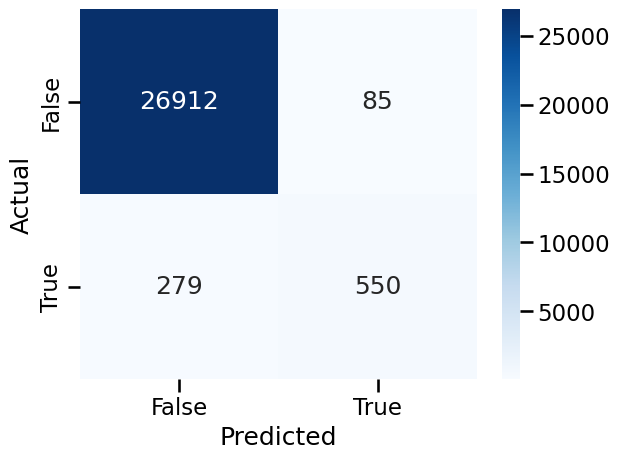

In [130]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

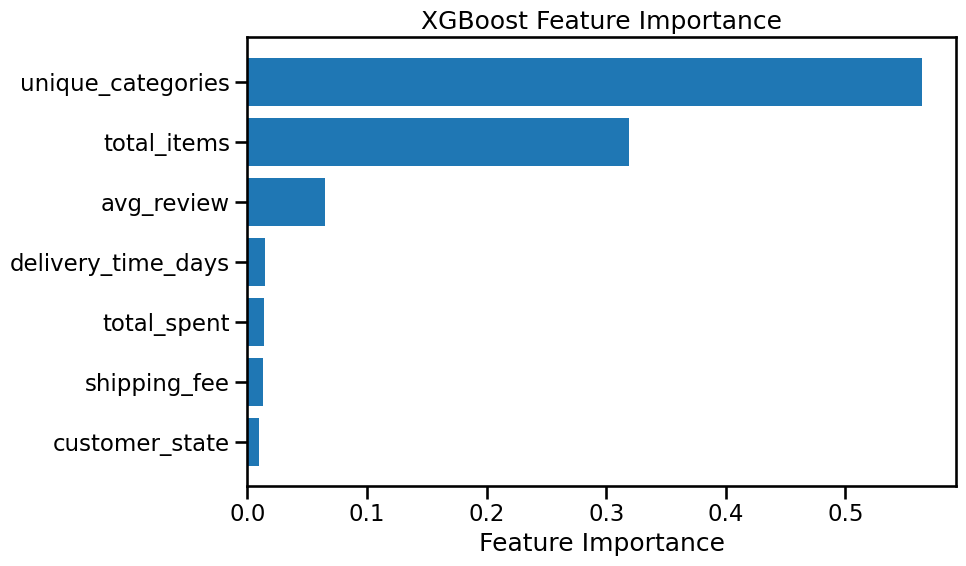

In [131]:
# Get feature importances from the trained XGBoost model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Optimisation using RandomSearch

In [159]:
param_dist = {
    'n_estimators': range(50, 201),
    'learning_rate': uniform(0.01, 0.3)  # draw floats from 0.01 to 0.31
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # number of combinations to try
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit to training data
random_search.fit(X_train, y_train)

# Best estimator and parameters
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Predict with best model
y_pred = best_model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'learning_rate': np.float64(0.22659963168004743), 'n_estimators': 87}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26997
           1       0.89      0.64      0.74       829

    accuracy                           0.99     27826
   macro avg       0.94      0.82      0.87     27826
weighted avg       0.99      0.99      0.99     27826



In [160]:
best_params = random_search.best_params_
import json

# Convert NumPy types to native Python types
cleaned_params = {k: float(v) if hasattr(v, 'item') else v for k, v in best_params.items()}
with open("best_xgb_params.json", "w") as f:
    json.dump(cleaned_params, f)
from google.colab import files
files.download("best_xgb_params.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [161]:
# Make predictions for training set (no threshold applied here usually)
y_train_pred = best_model.predict(X_train)

# Use predict_proba to get probabilities for the test set and apply a custom threshold
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
threshold = 0.45
y_test_pred = (y_test_pred_proba > threshold).astype(int)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
display(train_test_full_error)

,train,test
accuracy,0.989419,0.987242
precision,0.932133,0.881029
recall,0.695607,0.661037
f1,0.796685,0.755341


Text(0.5, 1.0, 'Confusion Matrix (Threshold = 0.45)')

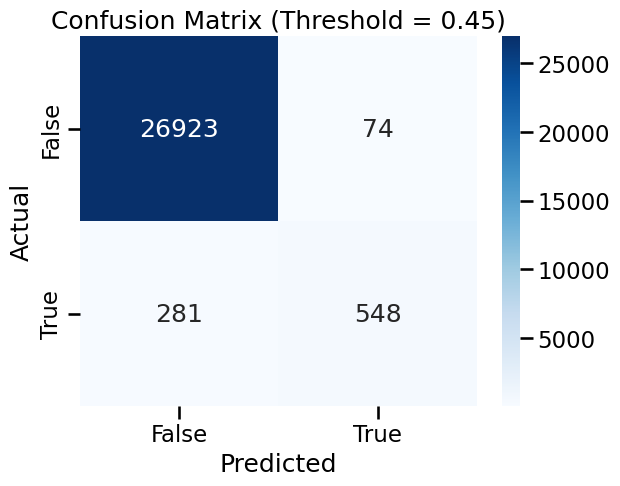

In [162]:
# Generate confusion matrix using 0.45 threshold
cm = confusion_matrix(y_test, y_test_pred)

# Plot it
sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Label formatting
labels = ['False', 'True']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title(f'Confusion Matrix (Threshold = {threshold})')


In [163]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities for the positive class (Repeat Buyer = 1)
y_train_pred_prob = best_model.predict_proba(X_train)
y_train_scores = y_train_pred_prob[:, 1]  # Probabilities for class 1

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)


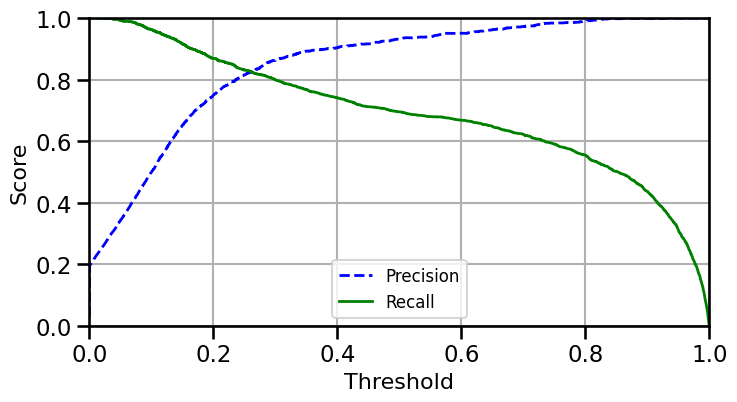

In [164]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 4))  # Make sure this is called before plotting
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.ylabel("Score", fontsize=16)
    plt.legend(loc="lower center", fontsize=12)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True)
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()


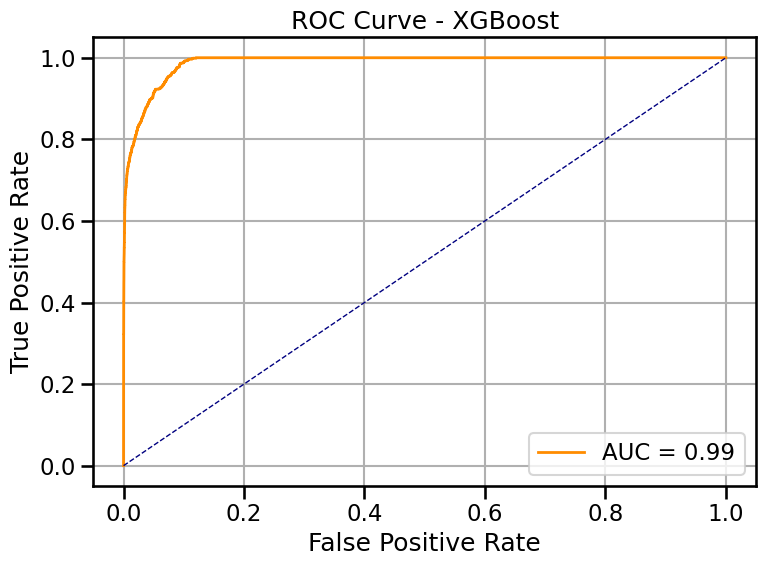

In [165]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (positive class)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [166]:
import joblib
joblib.dump(best_model, 'saved_model_XGBoost.pkl')

['saved_model_XGBoost.pkl']

In [167]:
print(y_test.value_counts())

repeat_buyer
0    26997
1      829
Name: count, dtype: int64


In [168]:
import json
with open("best_xgb_params.json") as f:
    notebook_params = json.load(f)
print("✅ Notebook Best Params:", notebook_params)


✅ Notebook Best Params: {'learning_rate': 0.22659963168004743, 'n_estimators': 87}


In [169]:
# Add missing columns in X_test that exist in X_train
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Drop any extra columns in X_test that don't exist in X_train
X_test = X_test[X_train.columns]


In [170]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score


In [171]:
# X_test = X_test.select_dtypes(exclude='object') # This line is no longer necessary as encoding is done earlier
y_proba = model.predict_proba(X_test)[:, 1]

# Compute and return evaluation metrics
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}\n")


Accuracy: 0.9870
Precision: 0.8923
Recall: 0.6393
F1 Score: 0.7449
AUC-ROC: 0.9881

